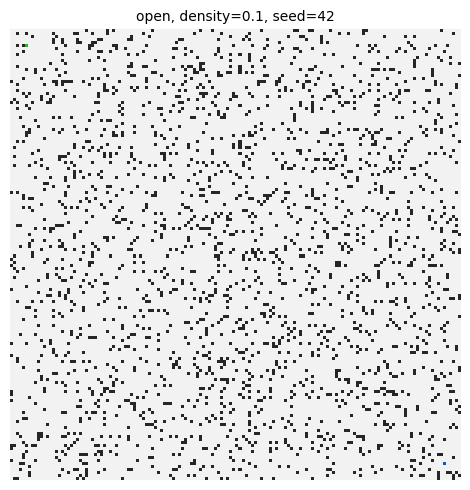

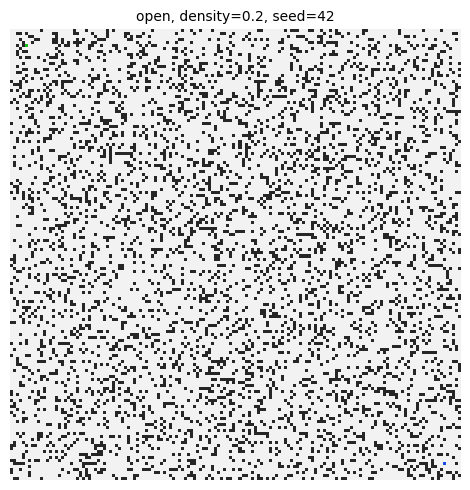

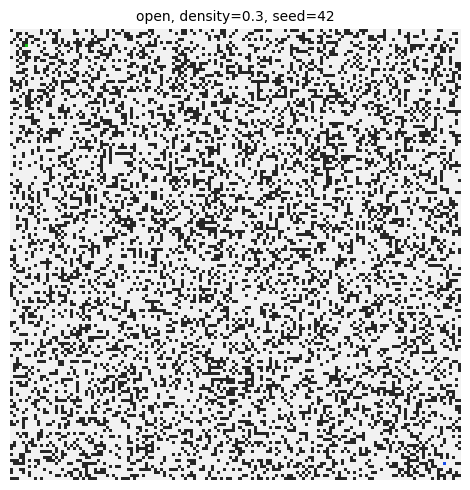

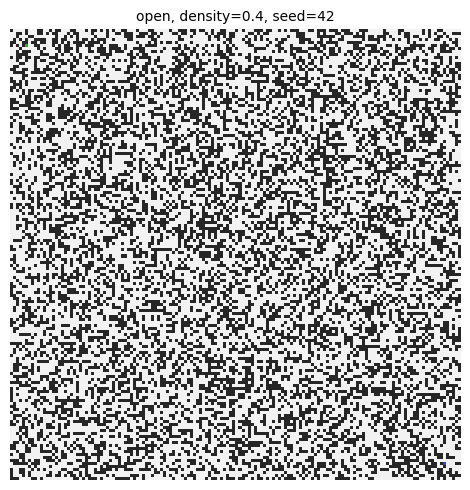

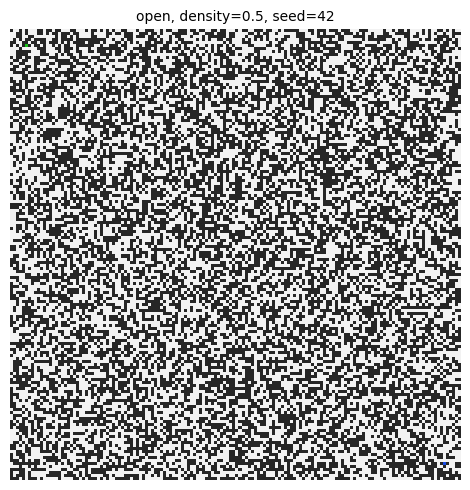

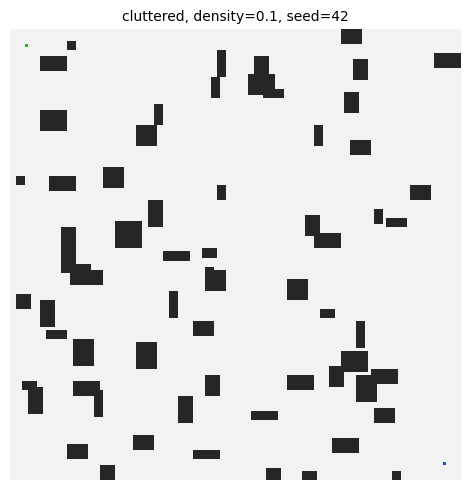

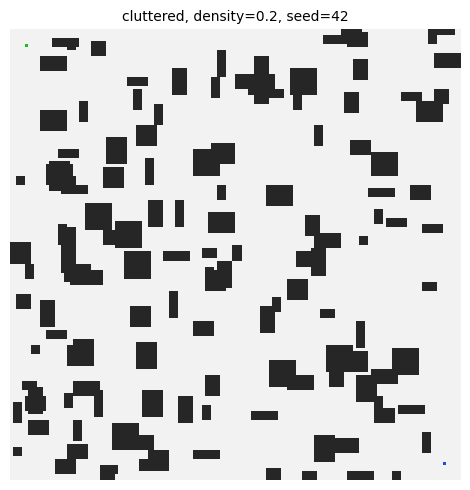

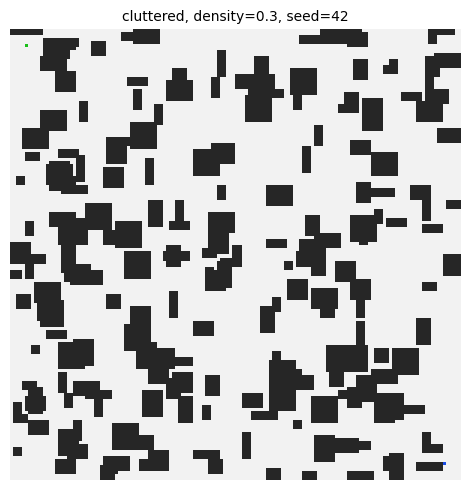

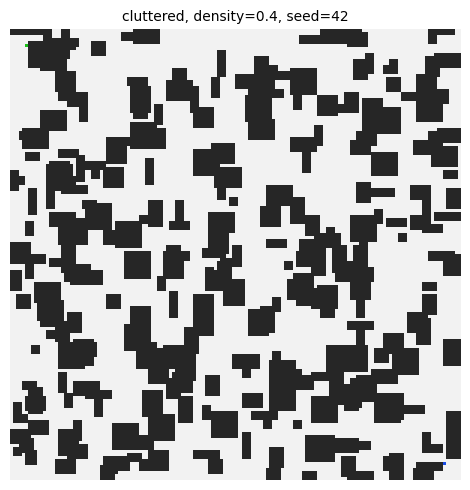

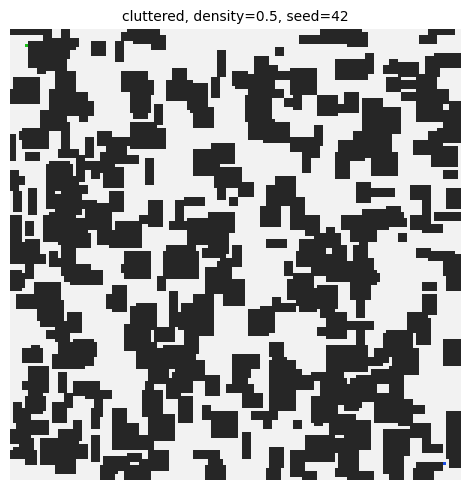

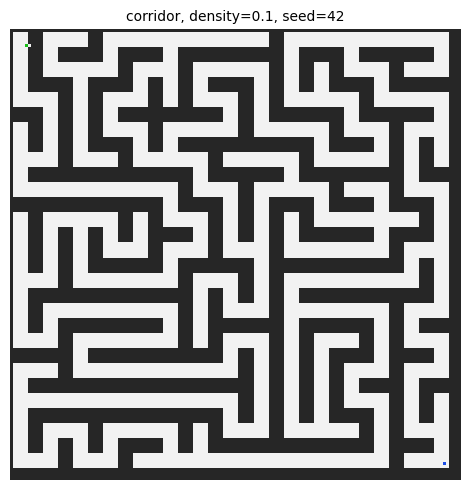

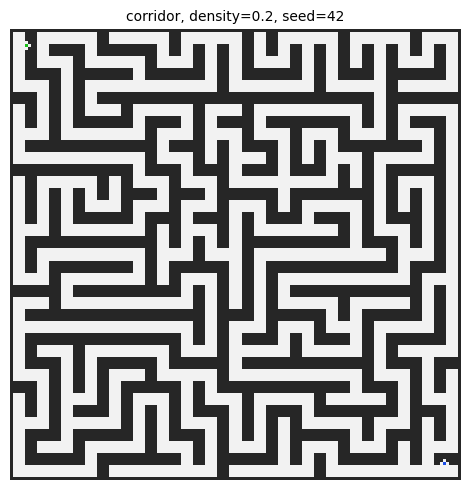

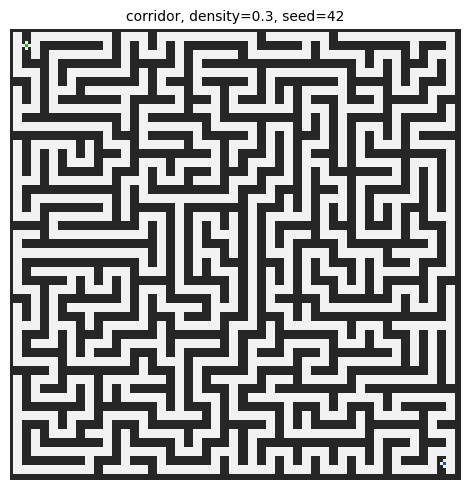

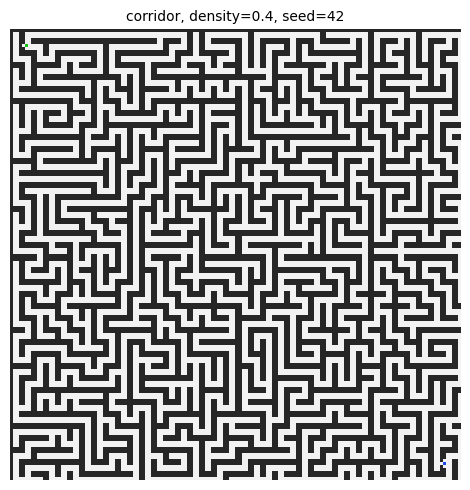

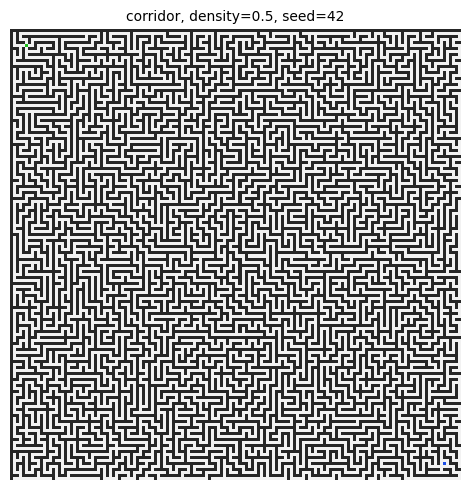

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import heapq
import random
from collections import defaultdict
import sys

GRID_ROWS = 150
GRID_COLS = 150
START = (5, 5)
GOAL  = (144, 144)

def has_path(grid, start, goal):
    """BFS to check if a valid path exists from start to goal"""
    if grid[start[0]][start[1]] == 1 or grid[goal[0]][goal[1]] == 1:
        return False
    visited = {start}
    queue = [start]
    while queue:
        r, c = queue.pop(0)
        if (r, c) == goal:
            return True
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1]:
                if grid[nr][nc] == 0 and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    queue.append((nr, nc))
    return False


def make_grid_open(rows, cols, density, rng):
    """random obstacles uniformly placed; regenerates if no valid path"""
    candidates = [(r, c) for r in range(rows) for c in range(cols)
                  if (r, c) != START and (r, c) != GOAL]
    n_obstacles = int(density * rows * cols)
    for _ in range(50):
        grid = np.zeros((rows, cols), dtype=np.int8)
        chosen = rng.choice(len(candidates), size=min(n_obstacles, len(candidates)), replace=False)
        for idx in chosen:
            r, c = candidates[idx]
            grid[r][c] = 1
        if has_path(grid, START, GOAL):
            return grid
    return grid


def make_grid_cluttered(rows, cols, density, rng):
    """random rectangular clusters; regenerates if no valid path"""
    total = int(density * rows * cols)
    for _ in range(50):
        grid = np.zeros((rows, cols), dtype=np.int8)
        filled = 0
        max_iter = 2000
        i = 0
        while filled < total and i < max_iter:
            i += 1
            r  = rng.integers(0, rows)
            c  = rng.integers(0, cols)
            hr = rng.integers(1, 5)
            hc = rng.integers(1, 5)
            for dr in range(-hr, hr + 1):
                for dc in range(-hc, hc + 1):
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < rows and 0 <= nc < cols:
                        if (nr, nc) not in (START, GOAL) and grid[nr][nc] == 0:
                            grid[nr][nc] = 1
                            filled += 1
        if has_path(grid, START, GOAL):
            return grid
    return grid

def make_grid_corridor(rows, cols, density, rng):
    """
    maze generated by recursive backtracking.
    passage width decreases with density: step 5 at 10% down to step 1 at 50%.
    """
    if density <= 0.10:
        step = 5
    elif density <= 0.20:
        step = 4
    elif density <= 0.30:
        step = 3
    elif density <= 0.40:
        step = 2
    else:
        step = 1

    for _ in range(10):
        grid = np.ones((rows, cols), dtype=np.int8)

        def carve(r, c):
            grid[r][c] = 0
            for pr in range(r, min(r + step, rows)):
                for pc in range(c, min(c + step, cols)):
                    grid[pr][pc] = 0
            directions = [(0,step*2),(0,-step*2),(step*2,0),(-step*2,0)]
            rng.shuffle(directions)
            for dr, dc in directions:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 1:
                    wr, wc = r + dr//2, c + dc//2
                    for pr in range(wr, min(wr + step, rows)):
                        for pc in range(wc, min(wc + step, cols)):
                            grid[pr][pc] = 0
                    carve(nr, nc)

        sys.setrecursionlimit(10000)
        carve(1, 1)

        grid[START[0]][START[1]] = 0
        grid[GOAL[0]][GOAL[1]]   = 0
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            sr, sc = START[0]+dr, START[1]+dc
            gr, gc = GOAL[0]+dr,  GOAL[1]+dc
            if 0 <= sr < rows and 0 <= sc < cols:
                grid[sr][sc] = 0
            if 0 <= gr < rows and 0 <= gc < cols:
                grid[gr][gc] = 0

        if has_path(grid, START, GOAL):
            return grid
    return grid

def make_grid(env_type, density, seed):
    """factory: returns a grid given environment type, density, and seed"""
    rng = np.random.default_rng(seed)
    if env_type == 'open':
        return make_grid_open(GRID_ROWS, GRID_COLS, density, rng)
    elif env_type == 'cluttered':
        return make_grid_cluttered(GRID_ROWS, GRID_COLS, density, rng)
    elif env_type == 'corridor':
        return make_grid_corridor(GRID_ROWS, GRID_COLS, density, rng)
    else:
        raise ValueError(f"unknown env_type: {env_type}")


def visualize_grid(grid, path=None, title=''):
    """plot grid; obstacles black, path red, start green, goal blue"""
    fig, ax = plt.subplots(figsize=(5, 5))
    display = np.zeros((*grid.shape, 3))
    display[grid == 1] = [0.15, 0.15, 0.15]
    display[grid == 0] = [0.95, 0.95, 0.95]
    if path:
        for (r, c) in path:
            display[r, c] = [0.9, 0.2, 0.2]
    display[START] = [0.1, 0.75, 0.1]
    display[GOAL]  = [0.1, 0.3,  0.9]
    ax.imshow(display, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── sanity check: all five densities for all three environment types
for env in ['open', 'cluttered', 'corridor']:
    for d in [0.10, 0.20, 0.30, 0.40, 0.50]:
        g = make_grid(env, density=d, seed=42)
        visualize_grid(g, title=f'{env}, density={d}, seed=42')

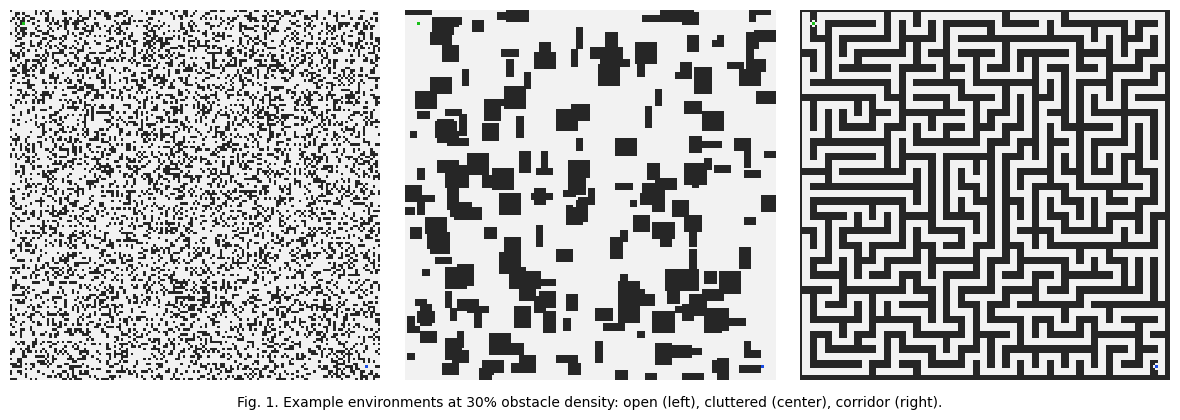

In [41]:
#figure 1: example environments at 30% density
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, env in zip(axes, ['open', 'cluttered', 'corridor']):
    g = make_grid(env, density=0.30, seed=42)
    display = np.zeros((*g.shape, 3))
    display[g == 1] = [0.15, 0.15, 0.15]
    display[g == 0] = [0.95, 0.95, 0.95]
    display[START] = [0.1, 0.75, 0.1]
    display[GOAL]  = [0.1, 0.3,  0.9]
    ax.imshow(display, interpolation='nearest')
    ax.axis('off')

fig.text(0.5, -0.03, 'Fig. 1. Example environments at 30% obstacle density: open (left), cluttered (center), corridor (right).',
         ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_environments.png', dpi=150, bbox_inches='tight')
plt.show()

A* [ euclidean]  path_cost=247.0782,  nodes_expanded=6434
A* [ manhattan]  path_cost=265.3209,  nodes_expanded=985
A* [  diagonal]  path_cost=247.0782,  nodes_expanded=5259


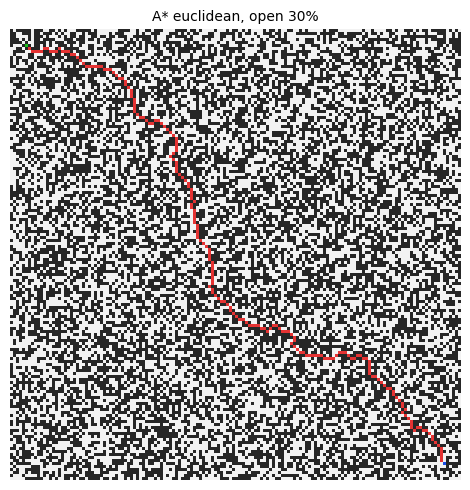

In [32]:
# ── 8-connected neighbors (shared by A* and Dijkstra)
MOVES = [(-1,0),(1,0),(0,-1),(0,1),   #cardinal
         (-1,-1),(-1,1),(1,-1),(1,1)]  #diagonal

SQRT2 = 2 ** 0.5

def neighbors_8(grid, r, c):
    """yield (neighbor_row, neighbor_col, step_cost) for all valid moves"""
    rows, cols = grid.shape
    for dr, dc in MOVES:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            cost = SQRT2 if (dr != 0 and dc != 0) else 1.0
            yield nr, nc, cost


# ── heuristics
def h_euclidean(r, c, goal):
    return ((r - goal[0])**2 + (c - goal[1])**2) ** 0.5

def h_manhattan(r, c, goal):
    return abs(r - goal[0]) + abs(c - goal[1])

def h_diagonal(r, c, goal):
    """chebyshev distance scaled for 8-connectivity step costs"""
    dr, dc = abs(r - goal[0]), abs(c - goal[1])
    return SQRT2 * min(dr, dc) + abs(dr - dc)


HEURISTICS = {
    'euclidean': h_euclidean,
    'manhattan': h_manhattan,
    'diagonal':  h_diagonal,
}

def path_cost(path):
    """euclidean distance between consecutive waypoints; valid for grid paths and RRT paths"""
    if path is None:
        return None
    total = 0.0
    for i in range(1, len(path)):
        dr = path[i][0] - path[i-1][0]
        dc = path[i][1] - path[i-1][1]
        total += (dr**2 + dc**2) ** 0.5
    return total

def astar(grid, start, goal, heuristic='euclidean'):
    """
    A* on an 8-connected grid.
    returns (path, time_s, nodes_expanded)
      path: list of (r,c) from start to goal, or None if no path exists
      time_s: wall-clock seconds
      nodes_expanded: number of nodes popped from the open set
    """
    h = HEURISTICS[heuristic]
    t0 = time.perf_counter()

    #open set: (f, g, r, c)
    open_set = [(h(start[0], start[1], goal), 0.0, start[0], start[1])]
    came_from = {}                    #(r,c) -> (r,c)
    g_score = {start: 0.0}
    closed = set()
    nodes_expanded = 0

    while open_set:
        f, g, r, c = heapq.heappop(open_set)
        if (r, c) in closed:
            continue
        closed.add((r, c))
        nodes_expanded += 1

        if (r, c) == goal:
            #reconstruct path
            path = []
            node = goal
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, time.perf_counter() - t0, nodes_expanded

        for nr, nc, step_cost in neighbors_8(grid, r, c):
            if (nr, nc) in closed:
                continue
            tentative_g = g + step_cost
            if tentative_g < g_score.get((nr, nc), float('inf')):
                came_from[(nr, nc)] = (r, c)
                g_score[(nr, nc)] = tentative_g
                f_new = tentative_g + h(nr, nc, goal)
                heapq.heappush(open_set, (f_new, tentative_g, nr, nc))

    return None, time.perf_counter() - t0, nodes_expanded

# ── sanity check
g = make_grid('open', density=0.50, seed=0)
for hname in HEURISTICS:
    path, t, expanded = astar(g, START, GOAL, heuristic=hname)
    print(f"A* [{hname:>10}]  path_cost={round(path_cost(path), 4)},  nodes_expanded={expanded}")

path, _, _ = astar(g, START, GOAL, heuristic='euclidean')
visualize_grid(g, path=path, title='A* euclidean, open 30%')

Dijkstra  path_cost=208.2914,  nodes_expanded=15699
A* eucl.  path_cost=208.2914,  nodes_expanded=4308
path_cost match: True


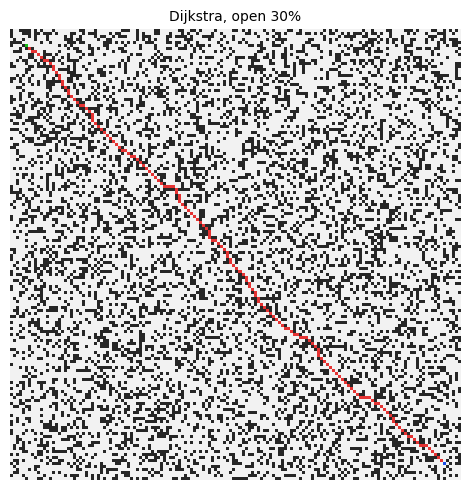

In [33]:
def dijkstra(grid, start, goal):
    """
    Dijkstra on an 8-connected grid.
    returns (path, time_s, nodes_expanded)
      path: list of (r,c) from start to goal, or None if no path exists
      time_s: wall-clock seconds
      nodes_expanded: number of nodes popped from the open set
    """
    t0 = time.perf_counter()

    #open set: (g, r, c)
    open_set = [(0.0, start[0], start[1])]
    came_from = {}
    g_score = {start: 0.0}
    closed = set()
    nodes_expanded = 0

    while open_set:
        g, r, c = heapq.heappop(open_set)
        if (r, c) in closed:
            continue
        closed.add((r, c))
        nodes_expanded += 1

        if (r, c) == goal:
            path = []
            node = goal
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, time.perf_counter() - t0, nodes_expanded

        for nr, nc, step_cost in neighbors_8(grid, r, c):
            if (nr, nc) in closed:
                continue
            tentative_g = g + step_cost
            if tentative_g < g_score.get((nr, nc), float('inf')):
                came_from[(nr, nc)] = (r, c)
                g_score[(nr, nc)] = tentative_g
                heapq.heappush(open_set, (tentative_g, nr, nc))

    return None, time.perf_counter() - t0, nodes_expanded


# ── sanity check
g = make_grid('open', density=0.30, seed=0)
path_d, t_d, exp_d = dijkstra(g, START, GOAL)
path_a, t_a, exp_a = astar(g, START, GOAL, heuristic='euclidean')

print(f"Dijkstra  path_cost={round(path_cost(path_d), 4)},  nodes_expanded={exp_d}")
print(f"A* eucl.  path_cost={round(path_cost(path_a), 4)},  nodes_expanded={exp_a}")
print(f"path_cost match: {round(path_cost(path_d), 4) == round(path_cost(path_a), 4)}")

visualize_grid(g, path=path_d, title='Dijkstra, open 30%')

RRT   path_cost=273.7229,  nodes=3035,   time=1553.96ms
RRT*  path_cost=231.1589,  nodes=6330,  time=10752.09ms


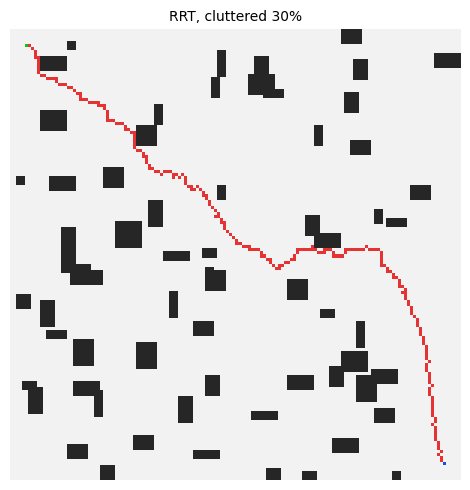

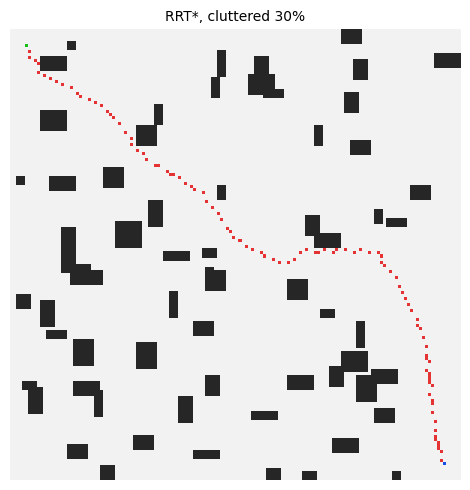

In [ ]:
def is_collision_free(grid, r1, c1, r2, c2, n_checks=10):
    """
    check n_checks interpolated points between (r1,c1) and (r2,c2).
    returns True if all points are free.
    """
    for i in range(n_checks + 1):
        t = i / n_checks
        r = r1 + t * (r2 - r1)
        c = c1 + t * (c2 - c1)
        gr, gc = int(round(r)), int(round(c))
        if not (0 <= gr < grid.shape[0] and 0 <= gc < grid.shape[1]):
            return False
        if grid[gr][gc] == 1:
            return False
    return True


def euclidean_dist(r1, c1, r2, c2):
    return ((r1 - r2)**2 + (c1 - c2)**2) ** 0.5


def rrt(grid, start, goal, max_iter=8000, step_size=1.0, goal_radius=1.5, seed=0):
    """
    RRT on a grid treated as continuous space.
    returns (path, time_s, nodes_expanded)
      path: list of (r,c) waypoints from start to goal, or None
      nodes_expanded: number of nodes added to the tree
    """
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()

    rows, cols = grid.shape
    #tree stored as list of (r,c); parent_map[i] = index of parent
    tree = [start]
    parent_map = {0: None}

    for iteration in range(max_iter):
        #sample random point; bias toward goal 10% of the time
        if rng.random() < 0.10:
            r_rand, c_rand = float(goal[0]), float(goal[1])
        else:
            r_rand = rng.uniform(0, rows - 1)
            c_rand = rng.uniform(0, cols - 1)

        #find nearest node in tree
        nearest_idx = min(range(len(tree)),
                          key=lambda i: euclidean_dist(tree[i][0], tree[i][1], r_rand, c_rand))
        r_near, c_near = tree[nearest_idx]

        #step from nearest toward random sample
        dist = euclidean_dist(r_near, c_near, r_rand, c_rand)
        if dist < 1e-6:
            continue
        ratio = min(step_size / dist, 1.0)
        r_new = r_near + ratio * (r_rand - r_near)
        c_new = c_near + ratio * (c_rand - c_near)

        #collision check
        if not is_collision_free(grid, r_near, c_near, r_new, c_new):
            continue

        #add new node
        new_idx = len(tree)
        tree.append((r_new, c_new))
        parent_map[new_idx] = nearest_idx

        #check if goal reached
        if euclidean_dist(r_new, c_new, goal[0], goal[1]) <= goal_radius:
            if is_collision_free(grid, r_new, c_new, goal[0], goal[1]):
                goal_idx = len(tree)
                tree.append((float(goal[0]), float(goal[1])))
                parent_map[goal_idx] = new_idx
                #reconstruct path
                path = []
                idx = goal_idx
                while idx is not None:
                    r, c = tree[idx]
                    path.append((int(round(r)), int(round(c))))
                    idx = parent_map[idx]
                path.reverse()
                return path, time.perf_counter() - t0, len(tree)

    return None, time.perf_counter() - t0, len(tree)


def rrt_star(grid, start, goal, max_iter=8000, step_size=1.0,
             goal_radius=1.5, neighbor_radius=3.0, seed=0):
    """
    RRT* on a grid treated as continuous space.
    adds rewiring step to improve path quality over time.
    returns (path, time_s, nodes_expanded)
    """
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()

    rows, cols = grid.shape
    tree = [start]
    parent_map = {0: None}
    cost = {0: 0.0}   #cost[i] = cost from start to node i
    best_goal_idx = None
    best_goal_cost = float('inf')

    for iteration in range(max_iter):
        #sample
        if rng.random() < 0.10:
            r_rand, c_rand = float(goal[0]), float(goal[1])
        else:
            r_rand = rng.uniform(0, rows - 1)
            c_rand = rng.uniform(0, cols - 1)

        #nearest
        nearest_idx = min(range(len(tree)),
                          key=lambda i: euclidean_dist(tree[i][0], tree[i][1], r_rand, c_rand))
        r_near, c_near = tree[nearest_idx]

        #steer
        dist = euclidean_dist(r_near, c_near, r_rand, c_rand)
        if dist < 1e-6:
            continue
        ratio = min(step_size / dist, 1.0)
        r_new = r_near + ratio * (r_rand - r_near)
        c_new = c_near + ratio * (c_rand - c_near)

        if not is_collision_free(grid, r_near, c_near, r_new, c_new):
            continue

        #find neighbors within radius for rewiring
        neighbors = [i for i in range(len(tree))
                     if euclidean_dist(tree[i][0], tree[i][1], r_new, c_new) <= neighbor_radius]

        #choose best parent among neighbors
        best_parent = nearest_idx
        best_cost = cost[nearest_idx] + euclidean_dist(r_near, c_near, r_new, c_new)
        for idx in neighbors:
            r_n, c_n = tree[idx]
            c_through = cost[idx] + euclidean_dist(r_n, c_n, r_new, c_new)
            if c_through < best_cost and is_collision_free(grid, r_n, c_n, r_new, c_new):
                best_cost = c_through
                best_parent = idx

        #add node
        new_idx = len(tree)
        tree.append((r_new, c_new))
        parent_map[new_idx] = best_parent
        cost[new_idx] = best_cost

        #rewire neighbors through new node if cheaper
        for idx in neighbors:
            r_n, c_n = tree[idx]
            c_through_new = best_cost + euclidean_dist(r_new, c_new, r_n, c_n)
            if c_through_new < cost[idx] and is_collision_free(grid, r_new, c_new, r_n, c_n):
                parent_map[idx] = new_idx
                cost[idx] = c_through_new

        #check goal
        if euclidean_dist(r_new, c_new, goal[0], goal[1]) <= goal_radius:
            if is_collision_free(grid, r_new, c_new, goal[0], goal[1]):
                goal_cost = best_cost + euclidean_dist(r_new, c_new, goal[0], goal[1])
                if goal_cost < best_goal_cost:
                    best_goal_cost = goal_cost
                    best_goal_idx = new_idx

    #reconstruct best path found
    if best_goal_idx is not None:
        path = [(int(round(goal[0])), int(round(goal[1])))]
        idx = best_goal_idx
        while idx is not None:
            r, c = tree[idx]
            path.append((int(round(r)), int(round(c))))
            idx = parent_map[idx]
        path.reverse()
        return path, time.perf_counter() - t0, len(tree)

    return None, time.perf_counter() - t0, len(tree)


# ── sanity check
g = make_grid('cluttered', density=0.10, seed=42)
path_rrt,  t_rrt,  n_rrt  = rrt(g,      START, GOAL, seed=42)
path_rsts, t_rsts, n_rsts = rrt_star(g, START, GOAL, seed=42)

print(f"RRT   path_cost={round(path_cost(path_rrt),  4) if path_rrt  else None},  nodes={n_rrt},   time={t_rrt*1000:.2f}ms")
print(f"RRT*  path_cost={round(path_cost(path_rsts), 4) if path_rsts else None},  nodes={n_rsts},  time={t_rsts*1000:.2f}ms")

visualize_grid(g, path=path_rrt,  title='RRT, cluttered 30%')
visualize_grid(g, path=path_rsts, title='RRT*, cluttered 30%')

In [35]:
ENV_TYPES   = ['open', 'cluttered', 'corridor']
DENSITIES   = [0.10, 0.20, 0.30, 0.40, 0.50]
N_TRIALS    = 30
ASTAR_HEURISTICS = ['euclidean', 'manhattan', 'diagonal']

#results dict: results[env][density][algorithm] = list of dicts, one per trial
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

total_conditions = len(ENV_TYPES) * len(DENSITIES)
condition = 0

for env in ENV_TYPES:
    for density in DENSITIES:
        condition += 1
        print(f"[{condition}/{total_conditions}] env={env}, density={density}", flush=True)

        for trial in range(N_TRIALS):
            seed = trial   #seeds 0-29, same across all conditions for reproducibility
            g = make_grid(env, density, seed)

            #a* with all three heuristics
            for hname in ASTAR_HEURISTICS:
                path, t, expanded = astar(g, START, GOAL, heuristic=hname)
                results[env][density][f'astar_{hname}'].append({
                    'path_cost':      path_cost(path),
                    'time_s':         t,
                    'nodes_expanded': expanded,
                    'success':        path is not None,
                })

            #dijkstra
            path, t, expanded = dijkstra(g, START, GOAL)
            results[env][density]['dijkstra'].append({
                'path_cost':      path_cost(path),
                'time_s':         t,
                'nodes_expanded': expanded,
                'success':        path is not None,
            })

            #rrt
            path, t, nodes = rrt(g, START, GOAL, seed=seed)
            results[env][density]['rrt'].append({
                'path_cost': path_cost(path),
                'time_s':    t,
                'nodes':     nodes,
                'success':   path is not None,
            })

            #rrt*
            path, t, nodes = rrt_star(g, START, GOAL, seed=seed)
            results[env][density]['rrt_star'].append({
                'path_cost': path_cost(path),
                'time_s':    t,
                'nodes':     nodes,
                'success':   path is not None,
            })

print("done.")

[1/15] env=open, density=0.1
[2/15] env=open, density=0.2
[3/15] env=open, density=0.3
[4/15] env=open, density=0.4
[5/15] env=open, density=0.5
[6/15] env=cluttered, density=0.1
[7/15] env=cluttered, density=0.2
[8/15] env=cluttered, density=0.3
[9/15] env=cluttered, density=0.4
[10/15] env=cluttered, density=0.5
[11/15] env=corridor, density=0.1
[12/15] env=corridor, density=0.2
[13/15] env=corridor, density=0.3
[14/15] env=corridor, density=0.4
[15/15] env=corridor, density=0.5
done.


In [36]:
#quick summary: success rates across all conditions
algorithms = ['astar_euclidean', 'astar_manhattan', 'astar_diagonal', 'dijkstra', 'rrt', 'rrt_star']
print(f"{'algorithm':<20} {'env':<12} {'density':<10} {'success_rate'}")
for algo in algorithms:
    for env in ENV_TYPES:
        for density in DENSITIES:
            trials = results[env][density][algo]
            rate = sum(t['success'] for t in trials) / len(trials)
            print(f"{algo:<20} {env:<12} {density:<10.2f} {rate:.2f}")

algorithm            env          density    success_rate
astar_euclidean      open         0.10       1.00
astar_euclidean      open         0.20       1.00
astar_euclidean      open         0.30       1.00
astar_euclidean      open         0.40       1.00
astar_euclidean      open         0.50       1.00
astar_euclidean      cluttered    0.10       1.00
astar_euclidean      cluttered    0.20       1.00
astar_euclidean      cluttered    0.30       1.00
astar_euclidean      cluttered    0.40       1.00
astar_euclidean      cluttered    0.50       1.00
astar_euclidean      corridor     0.10       1.00
astar_euclidean      corridor     0.20       1.00
astar_euclidean      corridor     0.30       1.00
astar_euclidean      corridor     0.40       1.00
astar_euclidean      corridor     0.50       1.00
astar_manhattan      open         0.10       1.00
astar_manhattan      open         0.20       1.00
astar_manhattan      open         0.30       1.00
astar_manhattan      open         0.40    

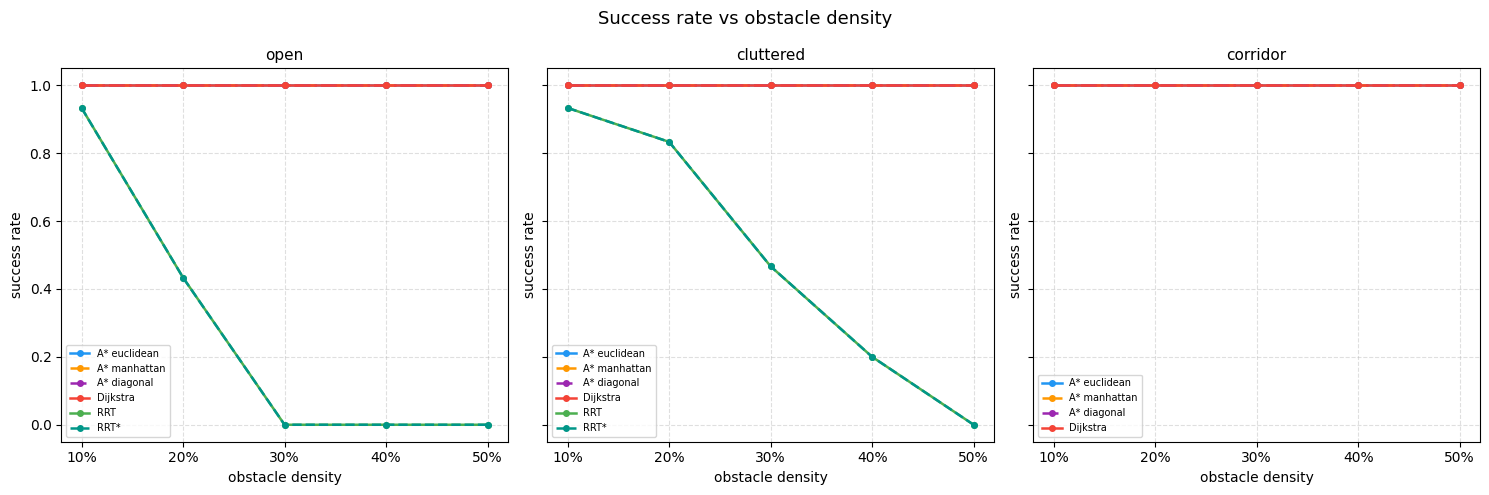

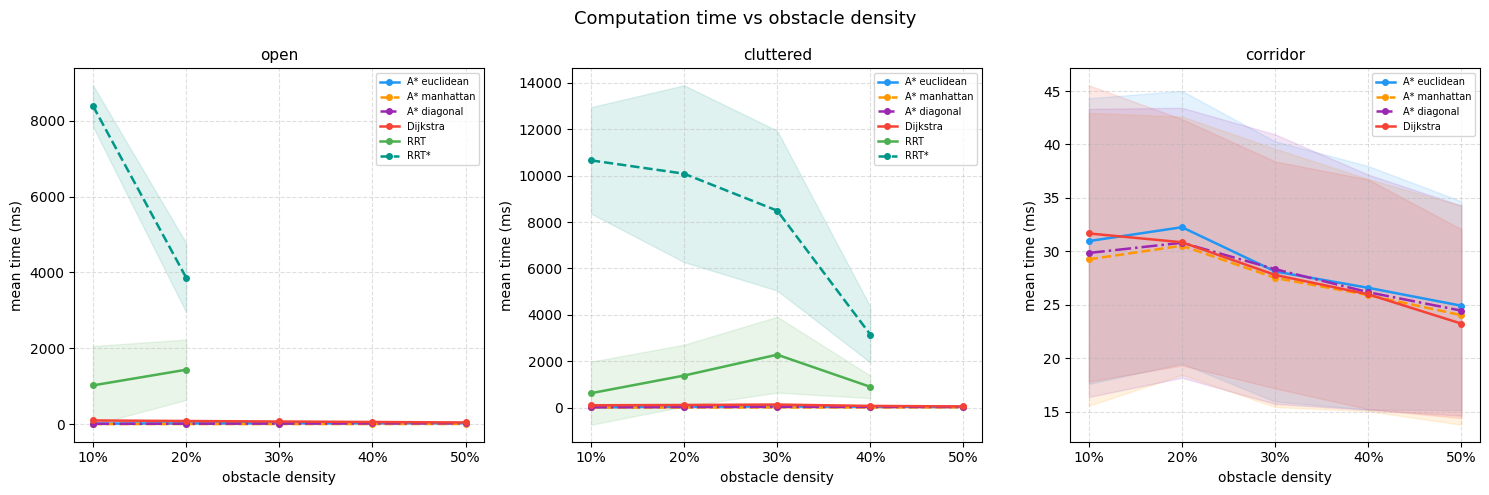

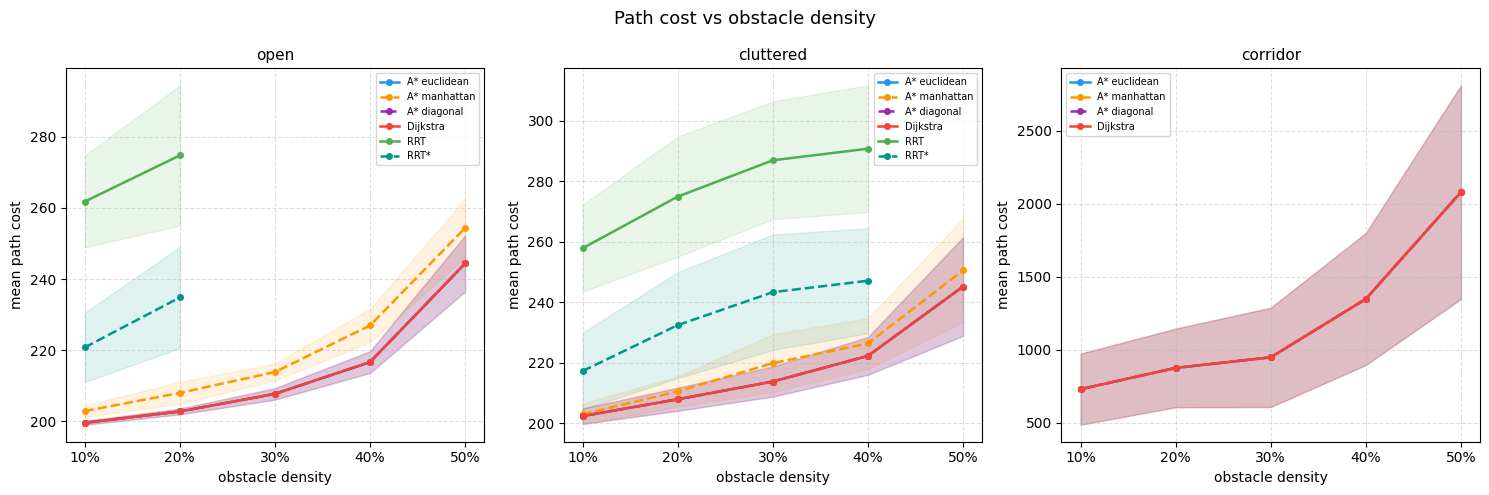

corridor 0.1:
  dijkstra = [965.9, 1037.9, 322.9, 264.2, 781.4]
  astar    = [965.9, 1037.9, 322.9, 264.2, 781.4]
corridor 0.2:
  dijkstra = [932.4, 897.9, 519.3, 1004.5, 836.1]
  astar    = [932.4, 897.9, 519.3, 1004.5, 836.1]
corridor 0.3:
  dijkstra = [1171.4, 1047.0, 893.4, 411.6, 1219.7]
  astar    = [1171.4, 1047.0, 893.4, 411.6, 1219.7]
corridor 0.4:
  dijkstra = [1306.8, 984.9, 1426.7, 709.4, 1785.8]
  astar    = [1306.8, 984.9, 1426.7, 709.4, 1785.8]
corridor 0.5:
  dijkstra = [1640.5, 2517.6, 1588.7, 1412.5, 2332.8]
  astar    = [1640.5, 2517.6, 1588.7, 1412.5, 2332.8]


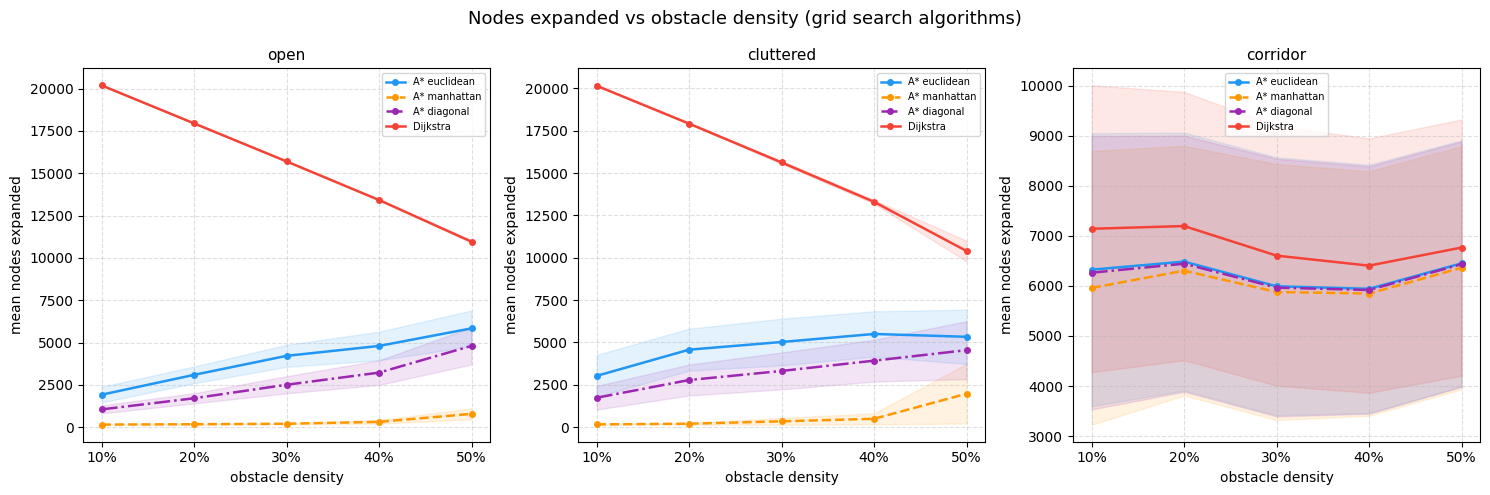

In [37]:
import matplotlib.pyplot as plt
import numpy as np

ALGORITHMS = {
    'astar_euclidean': 'A* euclidean',
    'astar_manhattan': 'A* manhattan',
    'astar_diagonal':  'A* diagonal',
    'dijkstra':        'Dijkstra',
    'rrt':             'RRT',
    'rrt_star':        'RRT*',
}

COLORS = {
    'astar_euclidean': '#2196F3',
    'astar_manhattan': '#FF9800',
    'astar_diagonal':  '#9C27B0',
    'dijkstra':        '#F44336',
    'rrt':             '#4CAF50',
    'rrt_star':        '#009688',
}

LINESTYLES = {
    'astar_euclidean': '-',
    'astar_manhattan': '--',
    'astar_diagonal':  '-.',
    'dijkstra':        '-',
    'rrt':             '-',
    'rrt_star':        '--',
}

DENSITY_LABELS = [0.10, 0.20, 0.30, 0.40, 0.50]


def extract_metric(results, env, density, algo, metric, success_only=True):
    """extract list of metric values from trials; optionally filter failed trials"""
    trials = results[env][density][algo]
    if success_only:
        return [t[metric] for t in trials if t['success'] and t[metric] is not None]
    return [t[metric] for t in trials if t[metric] is not None]


def plot_metric(metric_key, ylabel, title, success_only=True, scale=1.0,
                exclude_corridor_rrt=True):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    fig.suptitle(title, fontsize=13)

    for ax, env in zip(axes, ENV_TYPES):
        for algo, label in ALGORITHMS.items():
            means = []
            stds  = []
            for density in DENSITIES:
                #skip rrt/rrt* corridor if flagged
                if exclude_corridor_rrt and env == 'corridor' and algo in ('rrt', 'rrt_star'):
                    means.append(np.nan)
                    stds.append(np.nan)
                    continue
                vals = extract_metric(results, env, density, algo, metric_key, success_only)
                if len(vals) == 0:
                    means.append(np.nan)
                    stds.append(np.nan)
                else:
                    means.append(np.mean(vals) * scale)
                    stds.append(np.std(vals)  * scale)

            means = np.array(means)
            stds  = np.array(stds)
            x = np.array(DENSITIES)

            #only plot if at least one non-nan value
            if np.all(np.isnan(means)):
                continue

            ax.plot(x, means, label=label,
                    color=COLORS[algo], linestyle=LINESTYLES[algo], linewidth=1.8, marker='o', markersize=4)
            ax.fill_between(x, means - stds, means + stds,
                            alpha=0.12, color=COLORS[algo])

        ax.set_title(env, fontsize=11)
        ax.set_xlabel('obstacle density')
        ax.set_ylabel(ylabel)
        ax.set_xticks(DENSITIES)
        ax.set_xticklabels([f'{int(d*100)}%' for d in DENSITIES])
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


# ── plot 1: success rate (all trials, not just successful)
def plot_success_rate():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.suptitle('Success rate vs obstacle density', fontsize=13)

    for ax, env in zip(axes, ENV_TYPES):
        for algo, label in ALGORITHMS.items():
            rates = []
            for density in DENSITIES:
                if env == 'corridor' and algo in ('rrt', 'rrt_star'):
                    rates.append(np.nan)
                    continue
                trials = results[env][density][algo]
                rate = sum(t['success'] for t in trials) / len(trials)
                rates.append(rate)

            if np.all(np.isnan(rates)):
                continue

            ax.plot(DENSITIES, rates, label=label,
                    color=COLORS[algo], linestyle=LINESTYLES[algo],
                    linewidth=1.8, marker='o', markersize=4)

        ax.set_title(env, fontsize=11)
        ax.set_xlabel('obstacle density')
        ax.set_ylabel('success rate')
        ax.set_xticks(DENSITIES)
        ax.set_xticklabels([f'{int(d*100)}%' for d in DENSITIES])
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


plot_success_rate()

# ── plot 2: computation time (milliseconds, successful trials only)
plot_metric('time_s', 'mean time (ms)', 'Computation time vs obstacle density',
            success_only=True, scale=1000)

# ── plot 3: path cost (successful trials only)
plot_metric('path_cost', 'mean path cost', 'Path cost vs obstacle density',
            success_only=True, scale=1.0)

# ── plot 4: nodes expanded (A* and Dijkstra only)
def plot_nodes_expanded():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    fig.suptitle('Nodes expanded vs obstacle density (grid search algorithms)', fontsize=13)
    grid_algos = ['astar_euclidean', 'astar_manhattan', 'astar_diagonal', 'dijkstra']

    for ax, env in zip(axes, ENV_TYPES):
        for algo in grid_algos:
            means, stds = [], []
            for density in DENSITIES:
                vals = extract_metric(results, env, density, algo, 'nodes_expanded')
                means.append(np.mean(vals) if vals else np.nan)
                stds.append(np.std(vals)  if vals else np.nan)
            means, stds = np.array(means), np.array(stds)
            ax.plot(DENSITIES, means, label=ALGORITHMS[algo],
                    color=COLORS[algo], linestyle=LINESTYLES[algo],
                    linewidth=1.8, marker='o', markersize=4)
            ax.fill_between(DENSITIES, means - stds, means + stds,
                            alpha=0.12, color=COLORS[algo])

        ax.set_title(env, fontsize=11)
        ax.set_xlabel('obstacle density')
        ax.set_ylabel('mean nodes expanded')
        ax.set_xticks(DENSITIES)
        ax.set_xticklabels([f'{int(d*100)}%' for d in DENSITIES])
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

#debug: check corridor dijkstra path costs

for density in DENSITIES:
    trials_d = results['corridor'][density]['dijkstra']
    trials_a = results['corridor'][density]['astar_euclidean']
    costs_d = [t['path_cost'] for t in trials_d]
    costs_a = [t['path_cost'] for t in trials_a]
    print(f"corridor {density}:")
    print(f"  dijkstra = {[round(c,1) for c in costs_d[:5]]}")
    print(f"  astar    = {[round(c,1) for c in costs_a[:5]]}")

plot_nodes_expanded()

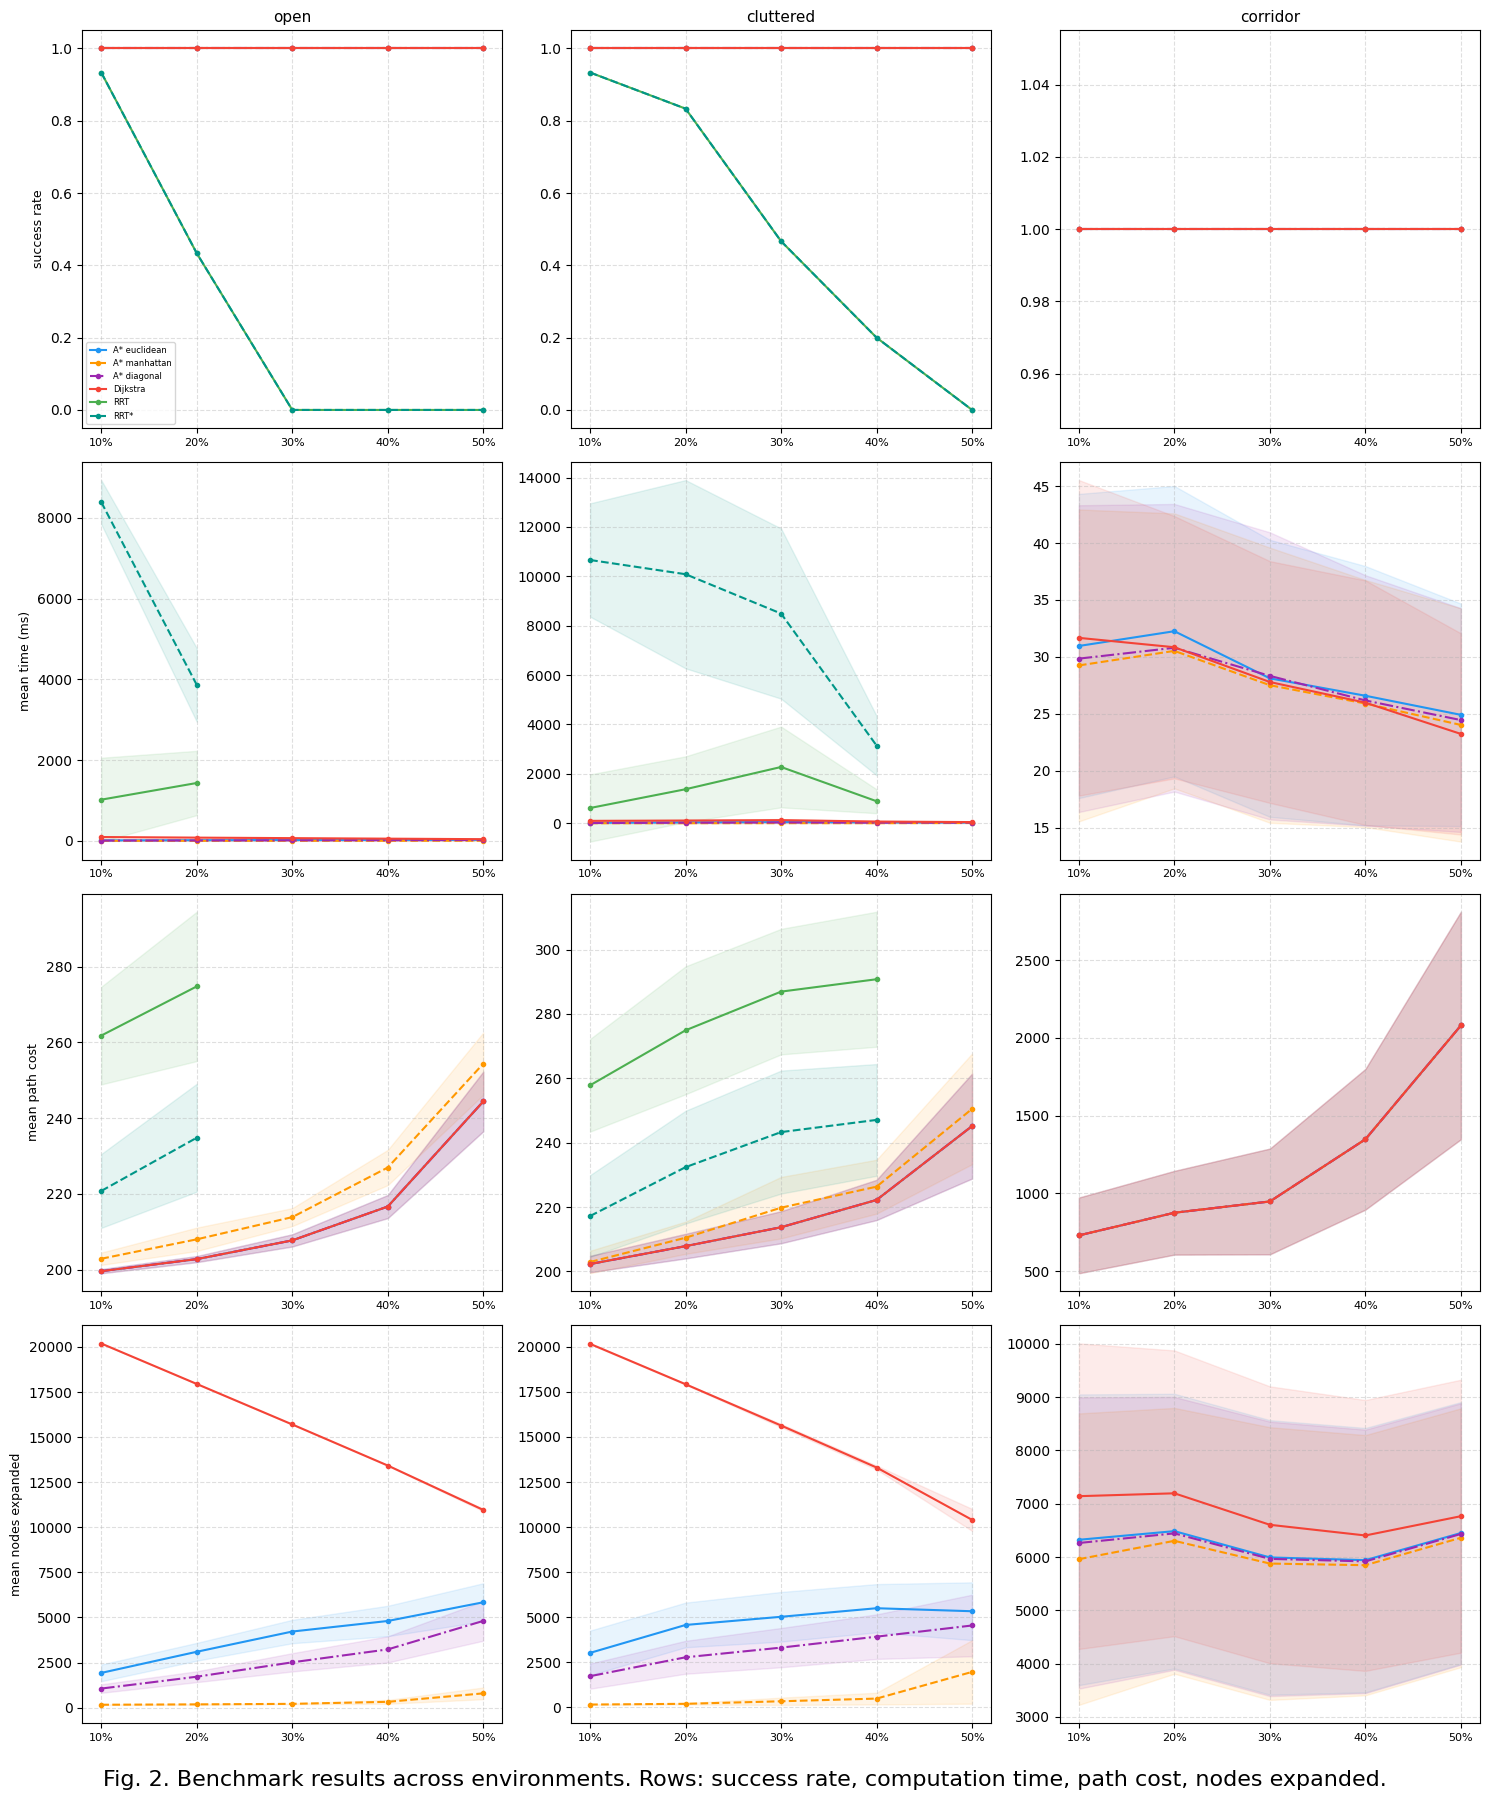

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))

metric_configs = [
    ('success', 'success rate', None),
    ('time_s', 'mean time (ms)', 1000),
    ('path_cost', 'mean path cost', 1.0),
    ('nodes_expanded', 'mean nodes expanded', 1.0),
]

for row, (metric_key, ylabel, scale) in enumerate(metric_configs):
    for col, env in enumerate(ENV_TYPES):
        ax = axes[row, col]

        if metric_key == 'success':
            algos_to_plot = ALGORITHMS.items()
        elif metric_key == 'nodes_expanded':
            algos_to_plot = [(k, v) for k, v in ALGORITHMS.items() if k.startswith('astar') or k == 'dijkstra']
        else:
            algos_to_plot = ALGORITHMS.items()

        for algo, label in algos_to_plot:
            if env == 'corridor' and algo in ('rrt', 'rrt_star'):
                continue

            if metric_key == 'success':
                vals = [sum(t['success'] for t in results[env][d][algo]) / len(results[env][d][algo])
                        for d in DENSITIES]
                ax.plot(DENSITIES, vals, label=label, color=COLORS[algo],
                        linestyle=LINESTYLES[algo], linewidth=1.5, marker='o', markersize=3)
            else:
                means, stds = [], []
                for d in DENSITIES:
                    success_only = metric_key != 'nodes_expanded'
                    vals = extract_metric(results, env, d, algo, metric_key, success_only=True)
                    if vals:
                        means.append(np.mean(vals) * (scale or 1))
                        stds.append(np.std(vals) * (scale or 1))
                    else:
                        means.append(np.nan)
                        stds.append(np.nan)
                means, stds = np.array(means), np.array(stds)
                ax.plot(DENSITIES, means, label=label, color=COLORS[algo],
                        linestyle=LINESTYLES[algo], linewidth=1.5, marker='o', markersize=3)
                ax.fill_between(DENSITIES, means - stds, means + stds, alpha=0.1, color=COLORS[algo])

        if row == 0:
            ax.set_title(env, fontsize=11)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(DENSITIES)
        ax.set_xticklabels([f'{int(d*100)}%' for d in DENSITIES], fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)
        if row == 0 and col == 0:
            ax.legend(fontsize=6)

plt.tight_layout()
plt.subplots_adjust(bottom=0.04)
fig.text(0.5, 0.005, 'Fig. 2. Benchmark results across environments. Rows: success rate, computation time, path cost, nodes expanded.',
         ha='center', fontsize=16)
plt.savefig('fig2_results.png', dpi=150, bbox_inches='tight')
plt.show()